In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# samma seed som i del 1
np.random.seed(42)

from health_tools import HealthAnalyzer

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

from health_tools import HealthAnalyzer

df = pd.read_csv("health_study_dataset.csv")
analyzer = HealthAnalyzer(df)

df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


Jag börjar med att importera de bibliotek jag använder genom hela analysen: NumPy för beräkningar, Pandas för datamanipulation och Matplotlib för visualisering.
Jag läser sedan in datan från den relativa sökvägen och skapar ett objekt av min klass HealthAnalyzer, som jag använder för att strukturera analysen.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

import importlib
import health_tools
importlib.reload(health_tools)

from health_tools import HealthAnalyzer

In [18]:
df = pd.read_csv("health_study_dataset.csv")

In [22]:
analyzer = HealthAnalyzer(df)
analyzer.basic_stats("systolic_bp")

{'mean': 149.178625, 'median': 149.4, 'min': 106.8, 'max': 185.9}

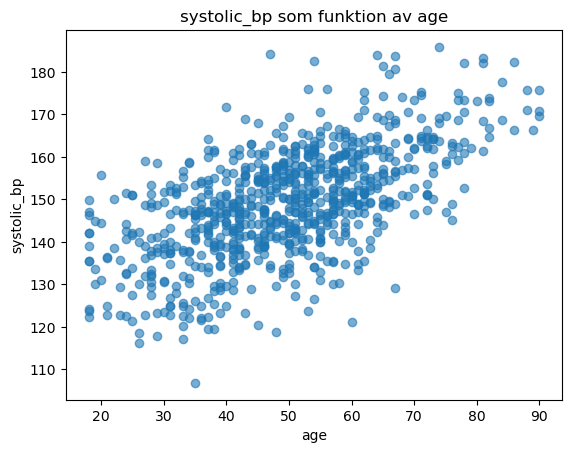

In [11]:
analyzer.plot_relation("age", "systolic_bp")

Här tittar jag på sambandet mellan ålder och systoliskt blodtryck med ett enkelt scatterplot.
Punkterna ligger ganska spritt men det syns en svag trend uppåt – högre ålder hänger ihop med något högre blodtryck.
Det här är också variablerna jag använder i min regressionsmodell senare.


In [12]:
reg_age_bp = analyzer.simple_regression("age", "systolic_bp")
reg_age_bp

{'slope': 0.5360255996690306,
 'intercept': 122.68488970435858,
 'r2': 0.36915159840526035}

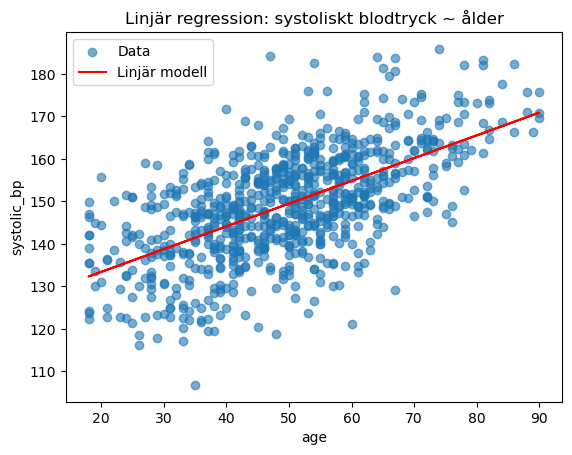

In [13]:

X = df["age"].values
y = df["systolic_bp"].values

slope = reg_age_bp["slope"]
intercept = reg_age_bp["intercept"]

y_pred = intercept + slope * X

plt.scatter(X, y, alpha=0.6, label="Data")
plt.plot(X, y_pred, color="red", label="Linjär modell")
plt.xlabel("age")
plt.ylabel("systolic_bp")
plt.title("Linjär regression: systoliskt blodtryck ~ ålder")
plt.legend()
plt.show()


Här använder jag en enkel linjär regression där ålder är den oberoende variabeln och systoliskt blodtryck är den beroende.
Modellen ger en lutning som är positiv, vilket betyder att blodtrycket i genomsnitt ökar något med åldern.
r²-värdet ligger runt ett ganska lågt värde, vilket visar att ålder bara förklarar en liten del av variationen i blodtrycket.
Det stämmer med att blodtryck påverkas av många andra faktorer än bara ålder.

In [21]:
import importlib, health_tools
importlib.reload(health_tools)
from health_tools import HealthAnalyzer

In [19]:
analyzer = HealthAnalyzer(df)
multi_res = analyzer.multi_regression_age_weight_bp()
multi_res

{'coef_age': 0.5389276325169826,
 'coef_weight': 0.177657521932679,
 'intercept': 109.49908144566373,
 'r2': 0.4052560814611623,
 'y_pred': array([151.90782144, 151.86603653, 155.89926007, 164.84178628,
        152.78390057, 146.47705855, 163.58637294, 151.52302941,
        146.64866155, 152.71323536, 145.81962627, 150.22553281,
        152.73675728, 138.29806189, 137.71189151, 142.82306977,
        140.82715156, 151.69453297, 144.44550939, 140.68482664,
        162.57958068, 148.76884058, 155.35417847, 131.35780674,
        143.5514656 , 152.52942387, 145.15008496, 148.71584167,
        147.41844452, 150.82371277, 139.22843276, 164.17869728,
        151.18508233, 145.62390465, 154.78011713, 135.63945247,
        154.61992701, 135.75160426, 139.16888209, 152.46431593,
        154.34778401, 149.26648054, 148.15894939, 148.95830879,
        138.35155804, 145.92016627, 141.48478273, 157.28518763,
        152.67760441, 137.10190087, 153.63099996, 146.98035523,
        148.47843458, 150.036

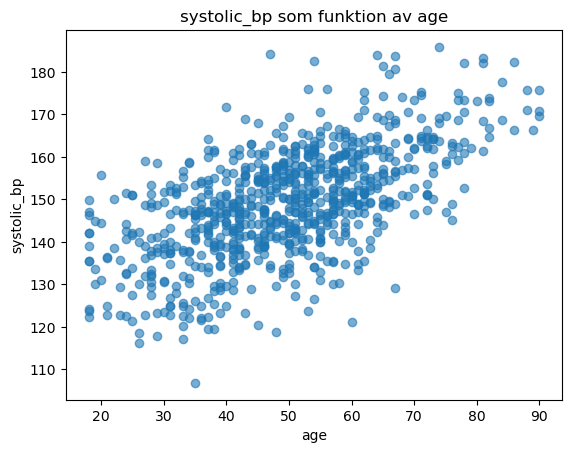

In [20]:
analyzer.plot_relation("age", "systolic_bp")

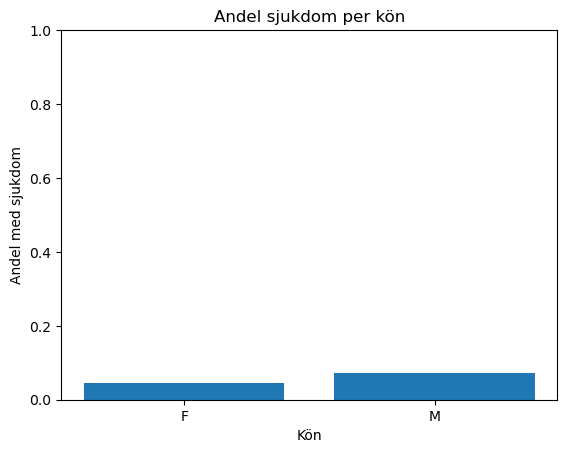

In [23]:
analyzer = HealthAnalyzer(df)
analyzer.plot_disease_by_sex()


Här tittar jag på hur vanligt det är med sjukdomen uppdelat på kön.
Stapeldiagrammet visar andelen deltagare med sjukdom i respektive grupp.
Det ser ut att finnas en viss skillnad mellan könen, men urvalet är inte jättestort så man ska vara lite försiktig med tolkningen.
Den här grafen kompletterar regressionerna genom att ge en enkel överblick över fördelningen av sjukdom i populationen.


Metodval och motivering

I den här delen har jag försökt strukturera upp arbetet mer än i del 1 genom att samla funktionerna i en egen klass. Det gör analysen lättare att återanvända och håller koden mer organiserad.

Till den statistiska delen använde jag både en enkel linjär regression (t.ex. ålder → systoliskt blodtryck) och en multipel regression där både ålder och vikt ingår. Multipel regression valde jag eftersom blodtryck påverkas av flera faktorer samtidigt, och modellen ger en bättre bild av hur variablerna samarbetar.

För visualisering gjorde jag både scatterplots och ett stapeldiagram över sjukdomsförekomst per kön. Den sista grafen valde jag för att visa en mer kategorisk jämförelse, vilket kompletterar regressionerna som fokuserar på kontinuerliga variabler.

Kodexempel och funktioner har utgått från genomgångarna i kursen och youtube-klipp. 
